# v3 — Daily Revenue & COGS Forecasting

Datathon 2026 — *The Gridbreakers* — Part 3 (Kaggle).

**Goal.** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 (548 days).

**Approach.**
1. Seasonal-naive baseline (Rev(t) = Rev(t − 364)) — mandatory floor.
2. SARIMAX(2,1,2) on log-revenue with weekly + yearly Fourier exog.
3. LightGBM on log target with calendar + target lags (364, 365, 728) + exogenous climatology/lag features.
4. Weighted ensemble tuned on CV MAE.

All feature engineering, training, validation, and inference logic lives in `pipeline.py` so this notebook stays linear and reproducible. Run top-to-bottom with 'Run All'.


## 1. Setup
Import the pipeline module and set up the project paths.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Ensure we run from the repo root so data/ paths resolve.
if os.path.basename(os.getcwd()) == 'v3':
    os.chdir('../..')
elif os.path.basename(os.getcwd()) == 'results':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())


cwd: /home/thangquang09/code/vinuni_hackathon


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from results.v3.pipeline import (
    REGIME_START, TRAIN_END, FOLDS,
    build_daily_panel, load_sample_submission,
    add_features, rolling_cv,
    fit_final_and_predict, feature_importance,
)


## 2. Load data and build the daily panel
We join `sales.csv` with aggregated exogenous signals (orders, web traffic, returns, inventory, promotions). Every signal is stored at daily resolution; lagging is applied later in `add_features` so the raw panel stays lossless.

In [3]:
panel = build_daily_panel()
sample = load_sample_submission()
print('Panel shape :', panel.shape)
print('Train window:', panel.index.min().date(), '->', panel.index.max().date())
print('Test window :', sample['Date'].min().date(), '->', sample['Date'].max().date())
panel.head(3)


Panel shape : (3833, 19)
Train window: 2012-07-04 -> 2022-12-31
Test window : 2023-01-01 -> 2024-07-01


,Revenue,COGS,n_orders,n_items,gross_rev,total_discount,promo_orders,avg_basket,promo_share,sessions,unique_visitors,page_views,bounce_rate,refund_amount,n_returns,stockout_rate,overstock_rate,mean_fill_rate,days_of_supply
Date,,,,,,,,,,,,,,,,,,,
2012-07-04,5123547.94,3982991.19,162,777,5123547.94,0.0,0,31626.839136,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.668354,0.594937,0.966075,93.253165
2012-07-05,2751773.45,2150580.23,97,428,2751773.45,0.0,0,28368.798454,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.668354,0.594937,0.966075,93.253165
2012-07-06,3054029.42,2517632.84,93,441,3054029.42,0.0,0,32839.026022,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.668354,0.594937,0.966075,93.253165


### Regime check (Insight 1 of the EDA)
The 2019 structural break in the revenue series drives our decision to cut training at 2019-01-01. Visual confirmation below.

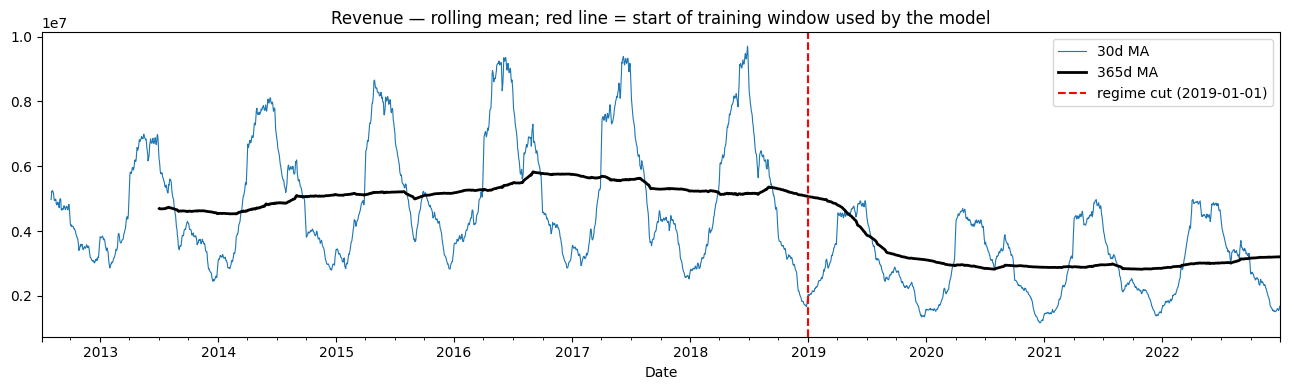

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
panel['Revenue'].rolling(30).mean().plot(ax=ax, lw=0.8, label='30d MA')
panel['Revenue'].rolling(365).mean().plot(ax=ax, lw=2.0, label='365d MA', color='black')
ax.axvline(REGIME_START, color='red', ls='--', label='regime cut (2019-01-01)')
ax.set_title('Revenue — rolling mean; red line = start of training window used by the model')
ax.legend(); plt.tight_layout(); plt.show()


## 3. Feature engineering

The pipeline builds the following feature groups (all forecast-time safe):

- **Calendar.** `dow`, `month`, `day`, `quarter`, `week_of_year`, `day_of_year`, boundary flags, VN public holidays.
- **Fourier.** K=2 weekly (period 7) + K=4 yearly (365.25) — captures May peak / Dec trough (Insight 2).
- **Target lags.** `{target}_lag_{364,365,728}` and `{target}_roll_{mean,std}_{W}_lag364` for W∈{7,28,91,364}.
- **Exogenous climatology.** Day-of-year average (2019–2022) of n_orders, avg_basket, promo_share, total_discount, web signals, refund, inventory ratios. Climatology is the only exogenous value guaranteed to be valid for every test date.
- **Exogenous lag-365 and lag-548.** To carry recent-year momentum (lag-365 is available for 2023 dates) and a strictly-safe fallback for 2024 dates (lag-548).

**Leakage checklist.** We do NOT use same-day `n_orders`, `COGS`, `refund`, or any rolling statistic that sees future data. Inventory is reduced to lagged values only (≥ 365 days). See `pipeline.add_features` for the full list.

In [5]:
feats_rev, fcols_rev = add_features(panel, 'Revenue')
print(f'Feature matrix: {feats_rev.shape}; {len(fcols_rev)} features')
print('Sample columns:'); print(fcols_rev[:12], '...')


Feature matrix: (3833, 77); 76 features
Sample columns:
['dow', 'day', 'month', 'quarter', 'week_of_year', 'day_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_weekend', 'year'] ...


## 4. Rolling-origin cross-validation

Two folds of 548 days each, respecting the 2019 regime cut (see EDA Insight 9):

| Fold | Train | Validation |
|------|-------|------------|
| 1 | 2019-01-01 → 2020-06-30 | 2020-07-01 → 2021-12-30 (548 d) |
| 2 | 2019-01-01 → 2021-06-30 | 2021-07-01 → 2022-12-30 (548 d) |

Every model is compared against seasonal-naive; the `ensemble_tuned` row uses CV-optimal weights.

In [6]:
cv_rev, stash_rev = rolling_cv(panel, 'Revenue', return_fold_preds=True)
cv_cogs, stash_cogs = rolling_cv(panel, 'COGS', return_fold_preds=True)
cv_all = pd.concat([cv_rev.assign(target='Revenue'), cv_cogs.assign(target='COGS')], ignore_index=True)
print('Revenue ensemble weights:', stash_rev['ensemble_weights'])
print('COGS ensemble weights:   ', stash_cogs['ensemble_weights'])
display(cv_all.groupby(['target','model'])[['MAE','RMSE','R2','Uplift_MAE_%']].mean().round(2))


Revenue ensemble weights: {'lgbm': 0.8499999999999999, 'sarimax': 0.0, 'naive': 0.15000000000000013}
COGS ensemble weights:    {'lgbm': 0.9499999999999998, 'sarimax': 0.0, 'naive': 0.050000000000000155}


MAE        RMSE    R2  Uplift_MAE_%
target  model                                                    
COGS    ensemble_tuned  468409.67   665114.59  0.76         42.39
        lightgbm        471627.29   665716.43  0.76         42.00
        sarimax         725785.17  1093554.86  0.35         10.78
        seasonal_naive  815000.10  1171204.33  0.26          0.00
Revenue ensemble_tuned  573505.65   805038.88  0.73         35.49
        lightgbm        581415.25   806513.44  0.73         34.61
        sarimax         810557.03  1222587.51  0.38          8.86
        seasonal_naive  890010.67  1287406.32  0.31          0.00

In [7]:
for t in ('Revenue', 'COGS'):
    df = cv_all[cv_all.target==t].pivot_table(index='model', columns='fold', values='MAE').round(0)
    print(f'=== {t} — MAE per fold ==='); print(df); print()


=== Revenue — MAE per fold ===
fold                   1         2
model                             
ensemble_tuned  545440.0  601571.0
lightgbm        556659.0  606171.0
sarimax         788548.0  832566.0
seasonal_naive  905443.0  874579.0

=== COGS — MAE per fold ===
fold                   1         2
model                             
ensemble_tuned  441319.0  495500.0
lightgbm        445542.0  497713.0
sarimax         695436.0  756135.0
seasonal_naive  837575.0  792425.0



## 5. Final training on 2019-01-01 → 2022-12-31 and 548-day inference

We retrain each base model on the full post-regime training window, then combine with the CV-tuned weights. LightGBM uses **recursive** substitution for `{target}_lag_364` on 2024 test dates (the lag source lies in 2023, which is itself test data).

In [8]:
submission = sample[['Date']].copy()
importances = {}
models = {}
for target in ('Revenue', 'COGS'):
    w = stash_rev['ensemble_weights'] if target == 'Revenue' else stash_cogs['ensemble_weights']
    preds, model, fcols = fit_final_and_predict(panel, sample, target, w)
    submission[target] = np.round(preds, 2)
    importances[target] = feature_importance(model, fcols)
    models[target] = model
    print(f'{target}: min={preds.min():,.0f}  max={preds.max():,.0f}  mean={preds.mean():,.0f}')
submission.head()


Revenue: min=884,735  max=8,401,234  mean=3,198,946


COGS: min=716,995  max=7,669,203  mean=2,677,279


,Date,Revenue,COGS
0,2023-01-01,2221888.74,1971395.91
1,2023-01-02,1261564.77,963672.27
2,2023-01-03,1101880.07,822565.15
3,2023-01-04,1141287.33,827427.21
4,2023-01-05,1167791.00,996862.65


### Quality gates — verify every requirement before writing submission.csv

In [9]:
assert len(submission) == 548
assert list(submission.columns) == ['Date', 'Revenue', 'COGS']
assert submission.isnull().sum().sum() == 0
assert (submission[['Revenue','COGS']] >= 0).all().all()
assert submission['Date'].reset_index(drop=True).equals(sample['Date'].reset_index(drop=True))
print('All quality gates passed.')


All quality gates passed.


## 6. Feature importance

LightGBM gain-based importance (how much each feature reduces loss across splits) is a first-pass view. We complement it with mean |SHAP| for the top features to verify magnitude and direction.

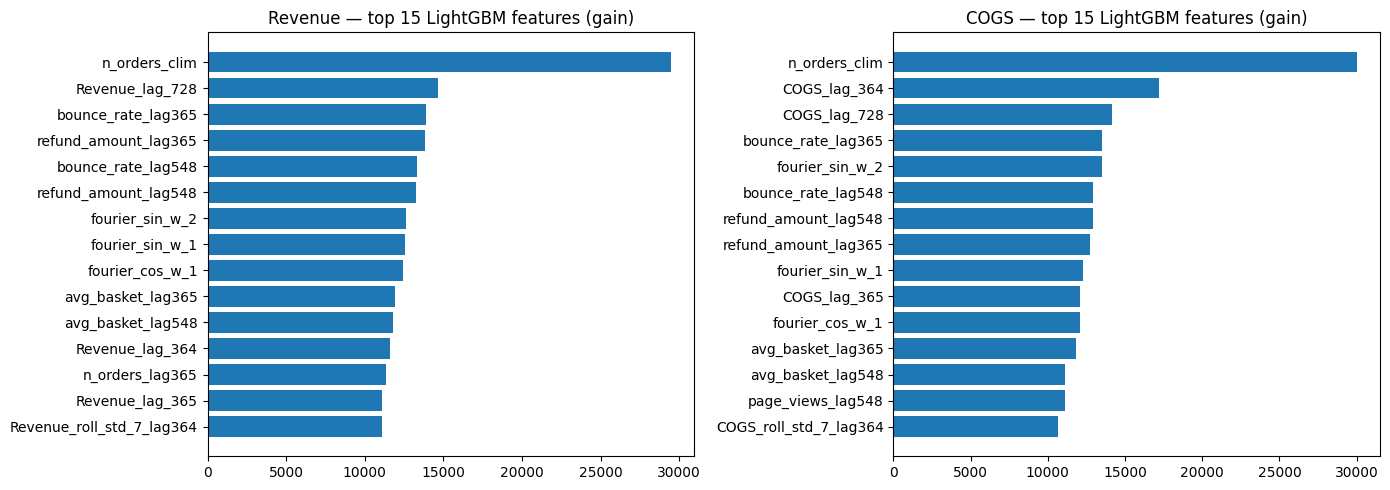

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t in zip(axes, ('Revenue', 'COGS')):
    top = importances[t].head(15).iloc[::-1]
    ax.barh(top['feature'], top['gain'])
    ax.set_title(f'{t} — top 15 LightGBM features (gain)')
plt.tight_layout(); plt.show()


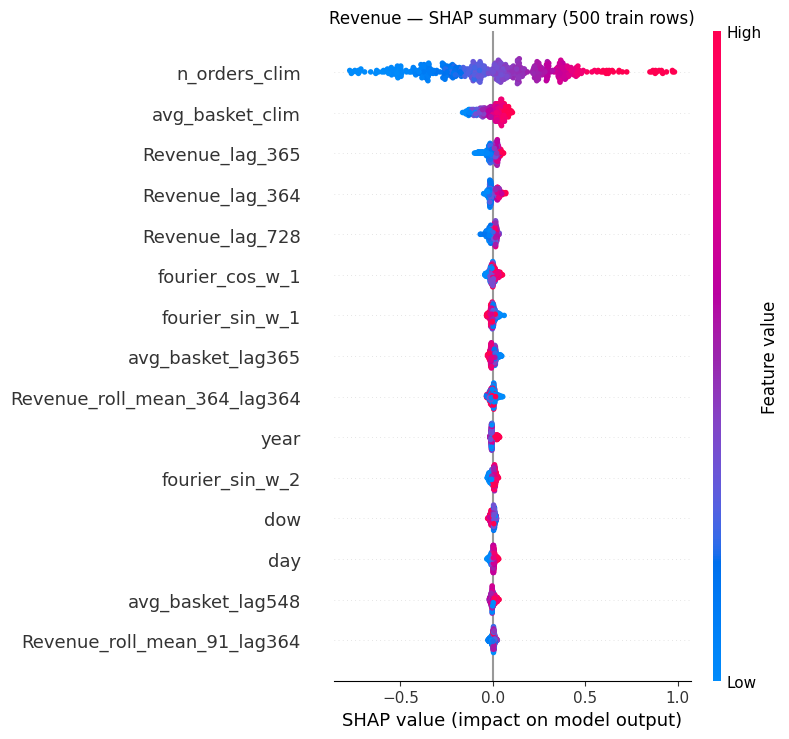

In [11]:
try:
    import shap
    for t in ('Revenue',):
        feats_t, fcols_t = add_features(panel, t)
        X_sample = feats_t.loc[REGIME_START:TRAIN_END, fcols_t].dropna().sample(500, random_state=0)
        expl = shap.TreeExplainer(models[t])
        sv = expl.shap_values(X_sample)
        shap.summary_plot(sv, X_sample, max_display=15, show=False)
        plt.title(f'{t} — SHAP summary (500 train rows)')
        plt.tight_layout(); plt.show()
except Exception as e:
    print('SHAP plot skipped:', e)


## 7. Save submission
Write `submission.csv` with Date in YYYY-MM-DD format, identical row order to `sample_submission.csv`.

In [12]:
out = submission.copy()
out['Date'] = out['Date'].dt.strftime('%Y-%m-%d')
out.to_csv('results/v3/submission.csv', index=False)
print('Saved', len(out), 'rows to results/v3/submission.csv')
out.head()


Saved 548 rows to results/v3/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2221888.74,1971395.91
1,2023-01-02,1261564.77,963672.27
2,2023-01-03,1101880.07,822565.15
3,2023-01-04,1141287.33,827427.21
4,2023-01-05,1167791.00,996862.65


## 8. Sanity: predicted vs. historical seasonality
Overlay the 548 predicted days against the last two complete historical years (2021–2022) to check that the annual shape looks right (May peak, Dec trough) and levels are in the 2022 range.

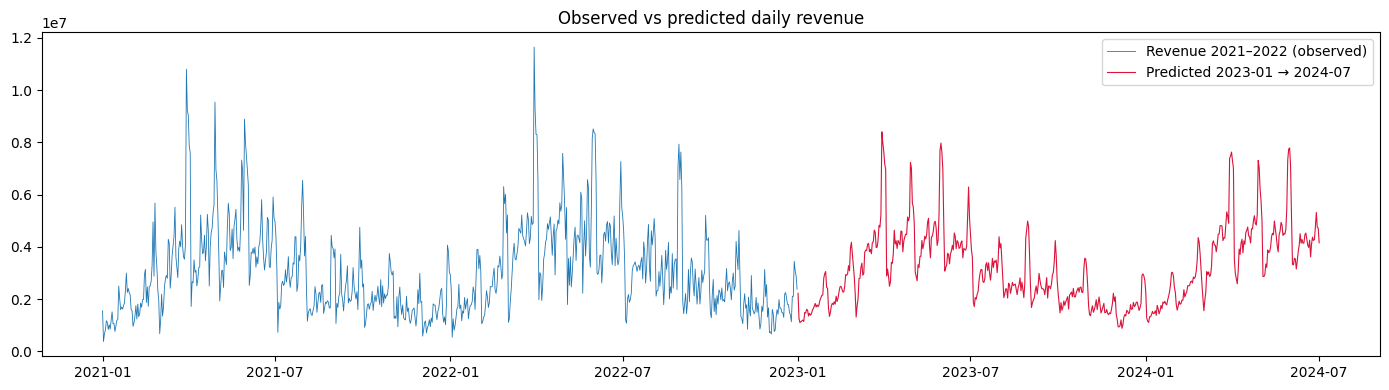

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
hist = panel.loc['2021-01-01':'2022-12-31', 'Revenue']
ax.plot(hist.index, hist.values, lw=0.6, label='Revenue 2021–2022 (observed)')
ax.plot(submission['Date'], submission['Revenue'], lw=0.8, color='crimson', label='Predicted 2023-01 → 2024-07')
ax.set_title('Observed vs predicted daily revenue')
ax.legend(); plt.tight_layout(); plt.show()
